In [32]:
# Specify where you want to save your results to
out_dir = '/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/symptom_on_lhs/cnrs/spearmanr/perm1000'

# Generate FWE Corrected R-Squared Map 
- Using maximum statistic correction
- Notes on controlling a regression:
    - Adding covariates to a regression will 'control' for them, but will almost always increase the R-squared. 
    - To 'remove' a covariate from the regression, you will want to regress a nuisance covariate OUT of the covariate of interest. 
        - This means your regressor will become the residuals from the regression of cov_1 ~ nuisance_cov1

Import Niftis
- These are EXPECTED to have subject IDs which are IDENTICAL to the subject IDs that go in the covarite DF column names below
- Column labels are subject IDs. 
- This is expected to ultimately have the form:

|        |  1 |  2 |  3 |  4 |  5 |  6 |  7 |  8 |  9 |  10 | ... |  40 |  41 |  42 |  43 |  45 |  46 |  47 |  48 |  49 |  50 |
|----------|------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|------------|-----|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|
| Voxel 1     | 3          | 4         | 7         | 2         | 2         | 2         | 9         | 4         | 7         | 5          | ... | 5           | 2           | 7           | 7           | 3           | 8           | 8           | 1           | 1           | 3           |
| . . .      | ...         | ...        | ...         | ...         | ...         | ...         | ...         | ...         | ...         | ...          | ... | ...           | ...           | ...           | ...           | ...           | ...           | 7           | ...           | ...           | ...           |
| Voxel N     | 2          | 1         | 0         | 1         | 3         | 4         | 9         | 5         | 8         | 6          | ... | 6           | 3           | 8           | 8           | 4           | 9           | 9           | 2           | 2           | 4           |

In [33]:
# Specify the path to your CSV file containing NIFTI paths
import_path = '/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/optimized_master_list.csv'
sheet = None

In [34]:
import pandas as pd

df = pd.read_csv(import_path)
f_for_import = df['selected_Nifti_File_Path'].dropna()

In [35]:
from calvin_utils.file_utils.import_functions import GiiNiiFileImport
giinii = GiiNiiFileImport(import_path=f_for_import, file_column="selected_Nifti_File_Path", file_pattern=None)
nimg_df = giinii.run()
nimg_df

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]


,-00272562/ses-07/unthresholded_tissue_segment_z_scores/sub-00272562_ses-07_composite_s4.nii.gz,-06930044/ses-04/unthresholded_tissue_segment_z_scores/sub-06930044_ses-04_composite_s4.nii.gz,-1355923/ses-02/unthresholded_tissue_segment_z_scores/sub-1355923_ses-02_composite_s4.nii.gz,-1406279/ses-02/unthresholded_tissue_segment_z_scores/sub-1406279_ses-02_composite_s4.nii.gz,-1539729/ses-01/unthresholded_tissue_segment_z_scores/sub-1539729_ses-01_composite_s4.nii.gz,-16067027/ses-03/unthresholded_tissue_segment_z_scores/sub-16067027_ses-03_composite_s4.nii.gz,-16721995/ses-07/unthresholded_tissue_segment_z_scores/sub-16721995_ses-07_composite_s4.nii.gz,-20508602/ses-03/unthresholded_tissue_segment_z_scores/sub-20508602_ses-03_composite_s4.nii.gz,-2071224/ses-07/unthresholded_tissue_segment_z_scores/sub-2071224_ses-07_composite_s4.nii.gz,-2368336/ses-02/unthresholded_tissue_segment_z_scores/sub-2368336_ses-02_composite_s4.nii.gz,...,-1847722/ses-Cor_3D_SPGR/unthresholded_tissue_segment_z_scores/sub-1847722_ses-Cor_3D_SPGR_composite_s4.nii.gz,-2823737/ses-Cor_3D_SPGR/unthresholded_tissue_segment_z_scores/sub-2823737_ses-Cor_3D_SPGR_composite_s4.nii.gz,-3699762/ses-8__Ax_3D_BRAVO/unthresholded_tissue_segment_z_scores/sub-3699762_ses-8__Ax_3D_BRAVO_composite_s4.nii.gz,-4029230/ses-AAHead_Scout/unthresholded_tissue_segment_z_scores/sub-4029230_ses-AAHead_Scout_composite_s4.nii.gz,-4058587/ses-Cor_3D_SPGR/unthresholded_tissue_segment_z_scores/sub-4058587_ses-Cor_3D_SPGR_composite_s4.nii.gz,-4747492/ses-Ax_BRAVO_Brain_Only/unthresholded_tissue_segment_z_scores/sub-4747492_ses-Ax_BRAVO_Brain_Only_composite_s4.nii.gz,-4760445/ses-Cor_3D_SPGR/unthresholded_tissue_segment_z_scores/sub-4760445_ses-Cor_3D_SPGR_composite_s4.nii.gz,-5075289/ses-Ax_Butler_BRAVO_Brain_Only/unthresholded_tissue_segment_z_scores/sub-5075289_ses-Ax_Butler_BRAVO_Brain_Only_composite_s4.nii.gz,-5623298/ses-AAHead_Scout/unthresholded_tissue_segment_z_scores/sub-5623298_ses-AAHead_Scout_composite_s4.nii.gz,-6868827/ses-_C_Ax_3D_VIBE_F_S_and_METS/unthresholded_tissue_segment_z_scores/sub-6868827_ses-_C_Ax_3D_VIBE_F_S_and_METS_composite_s4.nii.gz
0,0.311804,0.260006,0.907699,0.480671,0.610746,1.025452,1.794519,0.584199,0.406669,0.999496,...,0.428280,1.215562,0.084525,0.849091,0.310337,0.210884,0.710278,0.519039,1.059927,1.128737
1,0.260983,0.054359,0.375171,0.212982,0.739525,0.699720,1.715993,0.422126,0.182347,1.213712,...,0.238828,0.658419,0.051938,0.380079,0.417910,0.030460,0.635302,0.340229,0.893554,0.646584
2,0.448040,-0.255720,0.044208,-0.195767,0.901905,0.425841,1.545206,-0.010362,-0.296298,1.150485,...,-0.028115,-0.016907,-0.115284,0.011150,0.610889,-0.243090,0.236826,0.052952,0.345078,0.058161
3,0.646687,0.099408,0.432918,0.027832,0.685358,0.662217,1.576747,0.341363,0.065880,0.807294,...,0.293259,0.628594,-0.145756,0.456423,0.295261,0.160188,0.449294,0.141265,0.767828,1.097889
4,0.515091,-0.068538,0.038752,-0.024852,0.785114,0.270680,1.561264,0.106877,-0.166548,0.975531,...,0.219791,0.619734,-0.230696,0.108533,0.269909,-0.015174,0.264318,0.094158,0.585701,0.610738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228478,0.374313,-0.399312,-0.205633,-0.281462,0.260409,0.741361,2.108525,-0.035097,-0.024691,0.539800,...,0.807023,-0.245287,-0.309011,1.911887,0.201368,-0.236818,-0.113124,-0.602610,0.878845,0.772329
228479,0.903511,-0.135997,0.184616,0.870311,-0.038168,1.018902,3.319616,0.529142,1.107401,1.315633,...,1.984163,0.891479,1.063391,2.439370,-0.223632,0.190221,0.408065,0.002788,1.639386,1.411636
228480,1.054927,-0.238404,0.237625,0.493293,-0.105057,0.627563,2.956158,0.408010,0.528707,0.723018,...,1.644054,0.500630,0.457833,2.211249,-0.330788,-0.137296,0.281984,-0.517678,1.565324,0.820145
228481,0.648940,-0.456001,0.193012,0.036222,-0.005520,0.531053,2.430557,0.076137,0.011980,0.538962,...,1.357572,0.096344,0.042151,2.017669,-0.220328,-0.239060,-0.061740,-0.616384,1.329440,0.678335


Fix names

In [36]:
pre = 'sub-'
post = '_ses'

In [37]:
nimg_df = giinii.splice_colnames(nimg_df, pre, post)
nimg_df

,00272562,06930044,1355923,1406279,1539729,16067027,16721995,20508602,2071224,2368336,...,1847722,2823737,3699762,4029230,4058587,4747492,4760445,5075289,5623298,6868827
0,0.311804,0.260006,0.907699,0.480671,0.610746,1.025452,1.794519,0.584199,0.406669,0.999496,...,0.428280,1.215562,0.084525,0.849091,0.310337,0.210884,0.710278,0.519039,1.059927,1.128737
1,0.260983,0.054359,0.375171,0.212982,0.739525,0.699720,1.715993,0.422126,0.182347,1.213712,...,0.238828,0.658419,0.051938,0.380079,0.417910,0.030460,0.635302,0.340229,0.893554,0.646584
2,0.448040,-0.255720,0.044208,-0.195767,0.901905,0.425841,1.545206,-0.010362,-0.296298,1.150485,...,-0.028115,-0.016907,-0.115284,0.011150,0.610889,-0.243090,0.236826,0.052952,0.345078,0.058161
3,0.646687,0.099408,0.432918,0.027832,0.685358,0.662217,1.576747,0.341363,0.065880,0.807294,...,0.293259,0.628594,-0.145756,0.456423,0.295261,0.160188,0.449294,0.141265,0.767828,1.097889
4,0.515091,-0.068538,0.038752,-0.024852,0.785114,0.270680,1.561264,0.106877,-0.166548,0.975531,...,0.219791,0.619734,-0.230696,0.108533,0.269909,-0.015174,0.264318,0.094158,0.585701,0.610738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228478,0.374313,-0.399312,-0.205633,-0.281462,0.260409,0.741361,2.108525,-0.035097,-0.024691,0.539800,...,0.807023,-0.245287,-0.309011,1.911887,0.201368,-0.236818,-0.113124,-0.602610,0.878845,0.772329
228479,0.903511,-0.135997,0.184616,0.870311,-0.038168,1.018902,3.319616,0.529142,1.107401,1.315633,...,1.984163,0.891479,1.063391,2.439370,-0.223632,0.190221,0.408065,0.002788,1.639386,1.411636
228480,1.054927,-0.238404,0.237625,0.493293,-0.105057,0.627563,2.956158,0.408010,0.528707,0.723018,...,1.644054,0.500630,0.457833,2.211249,-0.330788,-0.137296,0.281984,-0.517678,1.565324,0.820145
228481,0.648940,-0.456001,0.193012,0.036222,-0.005520,0.531053,2.430557,0.076137,0.011980,0.538962,...,1.357572,0.096344,0.042151,2.017669,-0.220328,-0.239060,-0.061740,-0.616384,1.329440,0.678335


Import Covariates

**The CSV is expected to be in this format**
- sub column contents MUST match the names of the neuroimaging files above. 
    - ID column 
```
+-----+----------------------------+--------------+--------------+--------------+
| sub | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

In [38]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/optimized_master_list.csv'
sheet= None #'master_list_proper_subjects'

In [39]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()
data_df

,paths,Nifti_File_Path,subid,session,selected,selected_Nifti_File_Path,id,local_id,diagnosis,scan_type,...,TotalSection3Score,TotalSection4Score,TotalSection5Score,CNRSTotColAScore,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,oatgs
0,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,3,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
1,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,4,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
2,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,5,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
3,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,6,0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
4,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4760445,Cor_3D_SPGR,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-016,HA-01-016-7301,SCA3,Cor_3D_SPGR,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
176,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5075289,Ax_Butler_BRAVO_Brain_Only,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-035,HA-01-035-7301,SCA3,Ax_Butler_BRAVO_Brain_Only,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
177,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,Mag_Images,0,NaN,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-2.0,0.0,0.0,-5.0,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
178,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,AAHead_Scout,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-2.0,0.0,0.0,-5.0,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...


**Preprocess Your Data**

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [40]:
data_df.columns

Index(['paths', 'Nifti_File_Path', 'subid', 'session', 'selected',
       'selected_Nifti_File_Path', 'id', 'local_id', 'diagnosis', 'scan_type',
       ...
       'TotalSection3Score', 'TotalSection4Score', 'TotalSection5Score',
       'CNRSTotColAScore', 'CNRSTotColBScore', 'CNRSTotScore', 'roi_path',
       'conn_path', 'dataset', 'oatgs'],
      dtype='object', length=118)

In [41]:
outcome_col = 'CNRSTotScore'

In [42]:
drop_list = ['selected_Nifti_File_Path', outcome_col]

In [43]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,paths,Nifti_File_Path,subid,session,selected,selected_Nifti_File_Path,id,local_id,diagnosis,scan_type,...,TotalSection3Score,TotalSection4Score,TotalSection5Score,CNRSTotColAScore,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,oatgs
4,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
7,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,6930044,4,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
13,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1539729,1,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
15,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16067027,3,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
24,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16721995,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
26,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,20508602,3,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
33,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
36,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2368336,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-002,HA-01-002-7301,SCA6,C__Cor_T1_3D,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
38,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2369031,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-091,HA-01-091-7301,SCA27B,MPR_Coronal_Ref___Revised_,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy

**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

Set the parameters for dropping rows

In [44]:
# column = 'City'  # The column you'd like to evaluate
# condition = 'not'  # Thecondition to check ('equal', 'above', 'below', 'not')
# value = 'Toronto' # The value to compare against

In [45]:
# data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
# data_df

In [46]:
# data_df['subject'] = data_df['subject'].apply(lambda x: x.split('_S_')[1])
data_df


,paths,Nifti_File_Path,subid,session,selected,selected_Nifti_File_Path,id,local_id,diagnosis,scan_type,...,TotalSection3Score,TotalSection4Score,TotalSection5Score,CNRSTotColAScore,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,oatgs
4,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
7,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,6930044,4,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
13,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1539729,1,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
15,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16067027,3,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
24,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16721995,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
26,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,20508602,3,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
33,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,7,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
36,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2368336,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-002,HA-01-002-7301,SCA6,C__Cor_T1_3D,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
38,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2369031,2,1,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-091,HA-01-091-7301,SCA27B,MPR_Coronal_Ref___Revised_,...,0.0,0.0,0.0,0.0,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy

Regress out a Covariate

In [47]:
nimg_df.columns

Index(['00272562', '06930044', '1355923', '1406279', '1539729', '16067027',
       '16721995', '20508602', '2071224', '2368336', '2369031', '315616',
       '3241194', '40396335', '43218874', '4392765', '4401431', '4530107',
       '4552969', '4681221', '4722004', '4783569', '4792757', '5180657',
       '5199392', '5390756', '5410367', '5709549', '5737974', '5766687',
       '5997510', '6038408', '6227801', '6241170', '6350474', '6646073',
       '6803502', '7543232', '7610044', '7622589', '7665334', '7749218',
       '7871300', '7890257', '7997058', '8231339', '8254224', '8344492',
       '8786142', '1847722', '2823737', '3699762', '4029230', '4058587',
       '4747492', '4760445', '5075289', '5623298', '6868827'],
      dtype='object')

Regress values out of a Clinical Variable

In [48]:
# from calvin_utils.statistical_utils.regression_utils import RegressOutCovariates
# # use this code block to regress out covariates. Generally better to just include as covariates in a model..
# dependent_variable_list = ['Age']
# regressors = ['DIAGNOSIS_CURRENT']

# data_df, adjusted_dep_vars_list = RegressOutCovariates.run(df=data_df, dependent_variable_list=dependent_variable_list, covariates_list=regressors)
# print(adjusted_dep_vars_list)

Regress Values of out the Neuroimaging Variable

In [49]:
# pending

**Standardize Data**
- Enter Columns you Don't want to standardize into a list

In [50]:
# Remove anything you don't want to standardize
cols_not_to_standardize = ['subid']

In [51]:
data_df = cal_palm.standardize_columns(cols_not_to_standardize)
data_df

Unable to standardize column paths.
Unable to standardize column Nifti_File_Path.
Unable to standardize column session.
Unable to standardize column selected_Nifti_File_Path.
Unable to standardize column id.
Unable to standardize column local_id.
Unable to standardize column diagnosis.
Unable to standardize column scan_type.
Unable to standardize column roi_path.
Unable to standardize column conn_path.
Unable to standardize column dataset.
Unable to standardize column oatgs.


,paths,Nifti_File_Path,subid,session,selected,selected_Nifti_File_Path,id,local_id,diagnosis,scan_type,...,TotalSection3Score,TotalSection4Score,TotalSection5Score,CNRSTotColAScore,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,oatgs
4,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,7,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
7,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,6930044,4,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
13,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1539729,1,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
15,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16067027,3,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
24,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,16721995,7,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
26,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,20508602,3,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,NaN,NaN,NaN,NaN,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
33,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,7,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
36,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2368336,2,NaN,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,HA-01-002,HA-01-002-7301,SCA6,C__Cor_T1_3D,...,0.350524,0.388403,0.457144,0.508951,0.540521,0.534567,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...
38,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...

Choose Rows to Keep

In [52]:
print(data_df.columns)

Index(['paths', 'Nifti_File_Path', 'subid', 'session', 'selected',
       'selected_Nifti_File_Path', 'id', 'local_id', 'diagnosis', 'scan_type',
       ...
       'TotalSection3Score', 'TotalSection4Score', 'TotalSection5Score',
       'CNRSTotColAScore', 'CNRSTotColBScore', 'CNRSTotScore', 'roi_path',
       'conn_path', 'dataset', 'oatgs'],
      dtype='object', length=118)


In [53]:
subcol = 'subid'

In [54]:
col_to_keep_list = [subcol, outcome_col]

- The final DF is EXPECTED to have subject IDs which are IDENTICAL to the subject IDs that go in the neuroimaging DF column names above
- There should only be 1 variable  the row

|        |  1 |  2 |  3 |  4 |  5 |  6 |  7 |  8 |  9 |  10 | ... |  40 |  41 |  42 |  43 |  45 |  46 |  47 |  48 |  49 |  50 |
|----------|------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|------------|-----|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|
| Indep. Var.    | 3          | 4         | 7         | 2         | 2         | 2         | 9         | 4         | 7         | 5          | ... | 5           | 2           | 7           | 7           | 3           | 8           | 8           | 1           | 1           | 3           |

In [55]:
data_df=data_df.loc[:, col_to_keep_list]
data_df = data_df.T
data_df.columns = data_df.loc[subcol]
data_df = data_df.drop(subcol)
data_df.dropna(inplace=True, axis=1)
data_df

subid,272562.0,6930044.0,1355923.0,1539729.0,16067027.0,16721995.0,20508602.0,2071224.0,2368336.0,2369031.0,...,1847722.0,2823737.0,3699762.0,4029230.0,4058587.0,4747492.0,4760445.0,5075289.0,5623298.0,6868827.0
CNRSTotScore,0.534567,0.534567,0.534567,0.534567,0.534567,0.534567,0.534567,0.534567,0.534567,0.534567,...,0.534567,0.534567,0.534567,0.534567,0.534567,-4.501357,0.534567,0.534567,-0.398011,-0.304753


Is there a particular mask you want to use?
- MUST match the resolution of voxelwise data being analyzed. 
- If you set None, the voxelwise data will be used for thresholding. 
    - Values below mask_threshold (float) will be set to 0. 
- Warning: bad masking may result in failed experiments. Erroneous voxels outside the brain will influence the correction. 

In [56]:
mask_path = '/Users/cu135/Software_Local/calvin_utils_project/circuit_pyper/resources/MNI152_T1_2mm_brain_mask.nii'
mask_threshold = 0

Correlation method
- spearman or pearson

In [57]:
method = 'spearman'

Choose Max Stat Correction Method
- None | pseudo_var_smooth | var_smooth

In [58]:
max_stat_method = 'pseudo_var_smooth'

In [59]:
from calvin_utils.permutation_analysis_utils.correlation_fwe import CalvinFWEMap
for index, row in data_df.iterrows():
    calvin_fwe = CalvinFWEMap(neuroimaging_dataframe=nimg_df, 
                            variable_dataframe=data_df.loc[[index], :], 
                            mask_threshold=mask_threshold, 
                            mask_path=mask_path, out_dir=out_dir, 
                            method=method, max_stat_method=max_stat_method, vectorize=True)
    calvin_fwe.permutation_test_r_map(n_permutations=1000, debug=False)

Permuting: 100%|██████████| 1000/1000 [07:40<00:00,  2.17it/s]


95th percentile of permuted statistic:  0.3020027341079973
Image saved to: 
 /Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/symptom_on_lhs/cnrs/spearmanr/perm1000
Image saved to: 
 /Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/symptom_on_lhs/cnrs/spearmanr/perm1000
Image saved to: 
 /Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/optimzation/symptom_on_lhs/cnrs/spearmanr/perm1000


Visualize the FWE Corrected Image


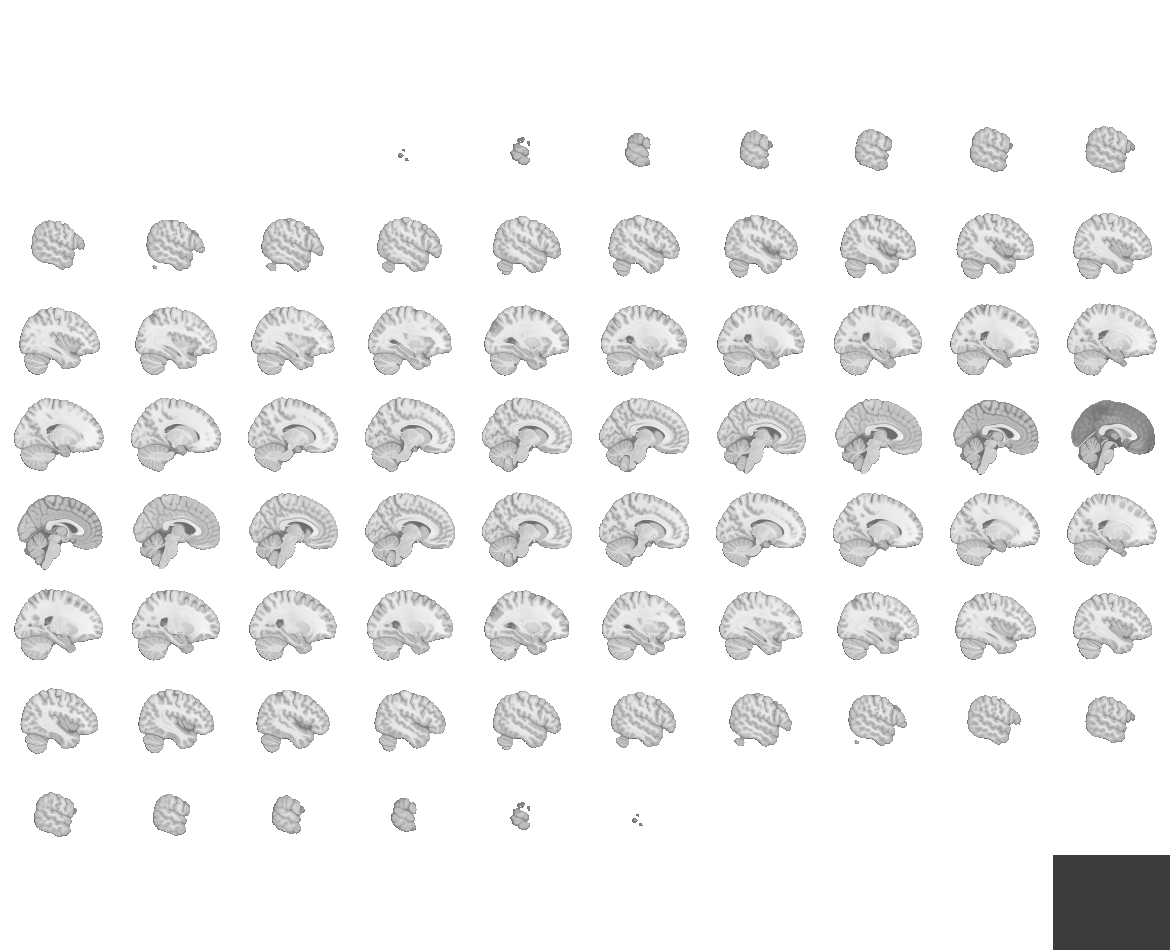
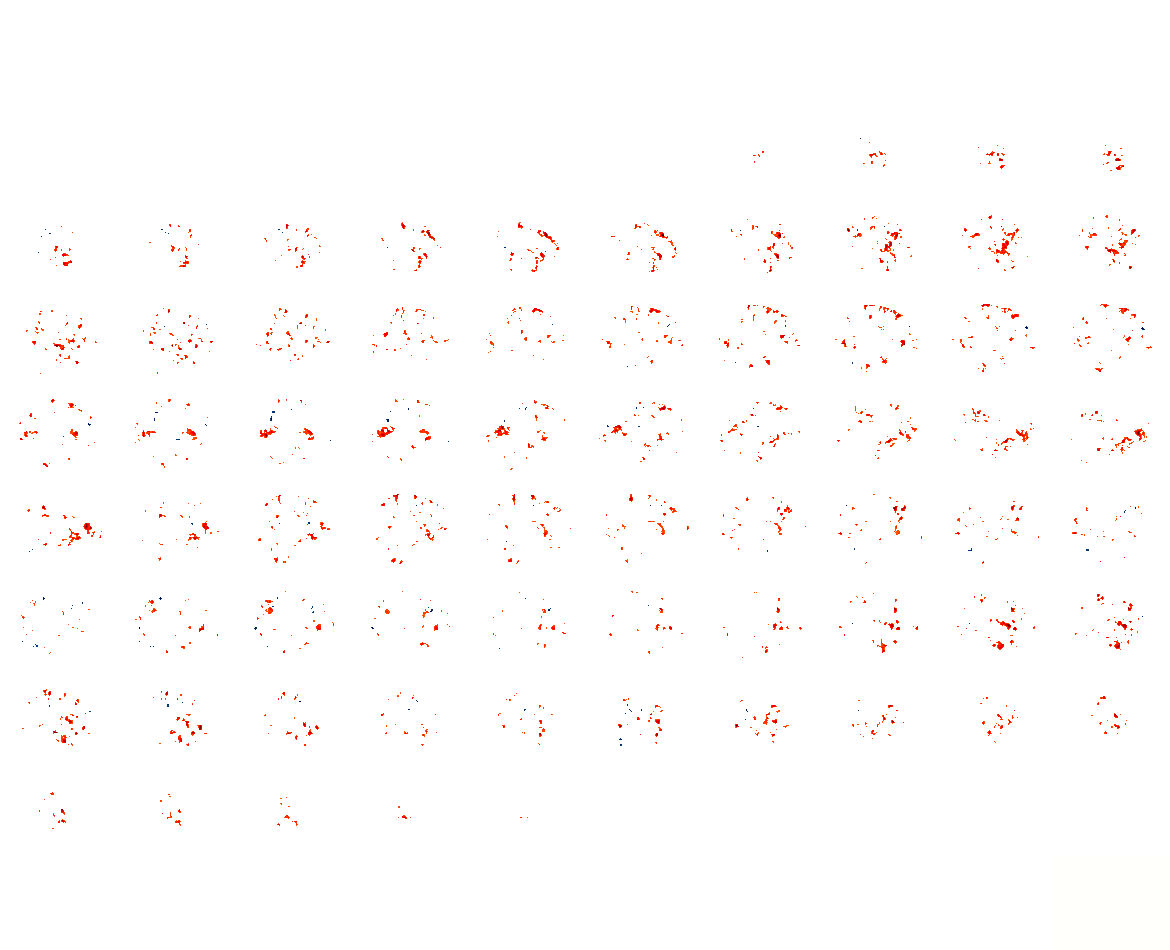

In [60]:
calvin_fwe.corrected_img

Visualize the P-Values (FWE Corrected) Used to Correct the Above


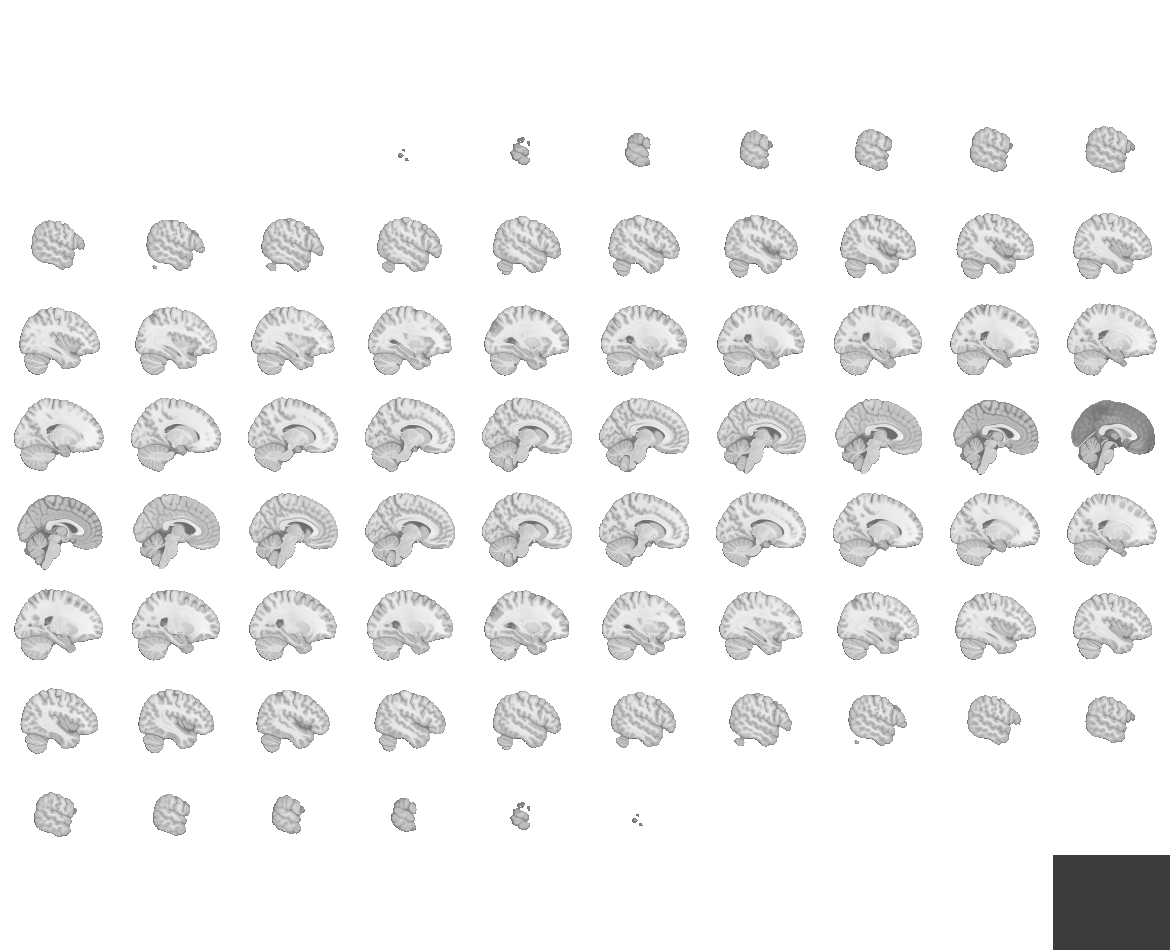
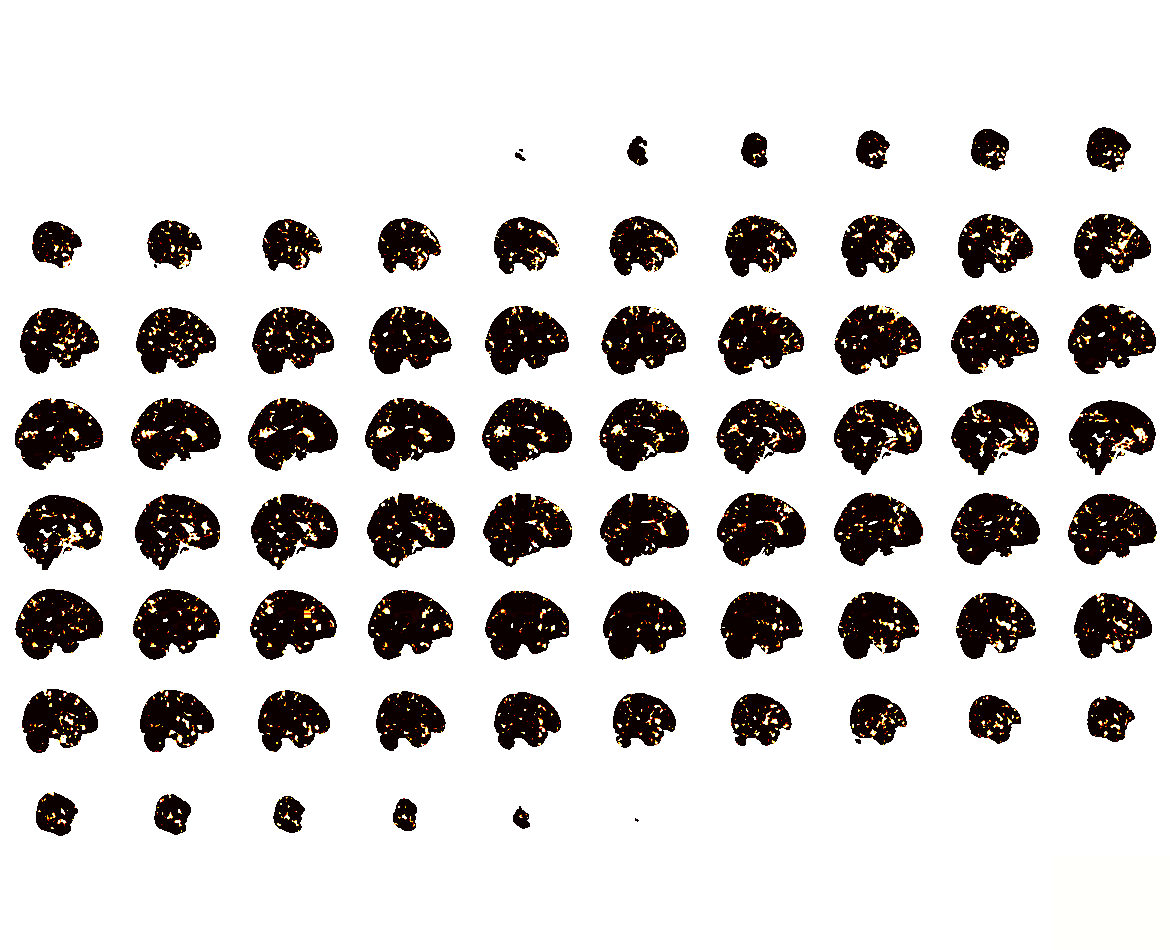

In [61]:
calvin_fwe.p_img

Visualize the Uncorrected Image


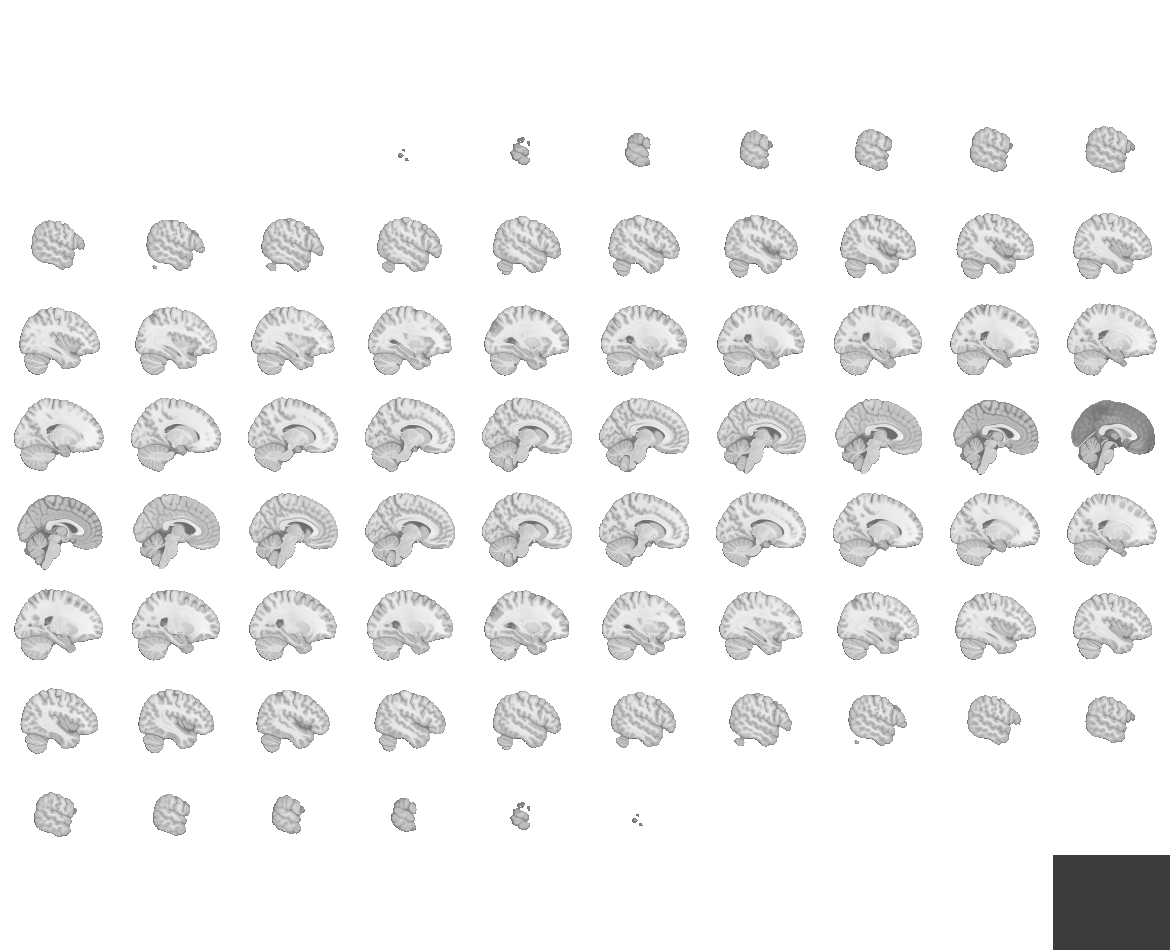
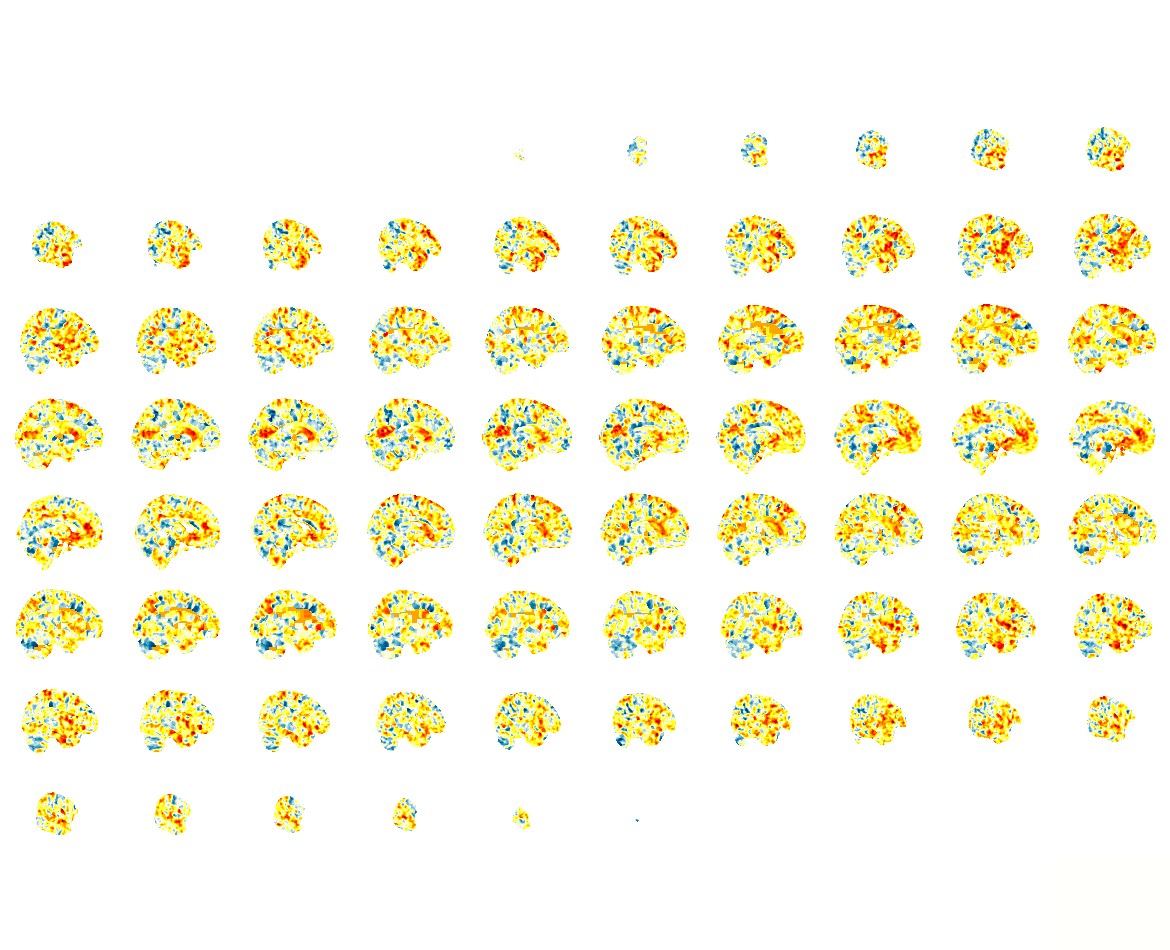

In [62]:
calvin_fwe.uncorrected_img